# Multirate controller: 1 kHz inner / 100 Hz outer / 10 Hz supervisor

Embedded motion-control stacks almost never run at a single rate. A current loop closes around an H-bridge at 1 kHz to keep up with the electrical time constant; a velocity loop above it ticks at 100 Hz because the encoder differentiation needs a quieter window; a position / supervisor layer ticks at 10 Hz because human-scale objectives change at human-scale speeds. Pretending all three live on the same clock either burns CPU on the supervisor or aliases the current loop into uselessness.

This notebook builds that cascade end-to-end on a permanent-magnet DC servo. We stand up the plant, close three loops at three different rates, route a multi-field measurement bus between them, and use `Diagram.print_schedule()` to confirm jaxonomy actually scheduled the events at the rates we asked for. The headline beats are T-105 (per-block sample-time inference + auto-inserted `RateTransition` blocks at rate-mismatch edges), T-123 (`RateTransition` / `Decimator`), and T-117 (`BusCreator` / `BusSelector`).

Reading time: ~20 minutes. Runtime on a laptop CPU: ~30 s end-to-end.

## Prerequisites

We assume familiarity with `DiagramBuilder`, `LeafSystem`, and `PIDDiscrete` — see the introductory [primitives notebook](primitives.ipynb) and the [PID tuning tutorial](pid_tuning.ipynb). Background on `simulate` + `SimulatorOptions` matches [actuator delay identification](actuator_delay_identification.ipynb). For single-rate frequency analysis on the same plant family, see [linearization workflow](linearization_workflow.ipynb).

## The plant — PM DC motor

A permanent-magnet DC motor has two coupled first-order subsystems: electrical (inductor + back-EMF) and mechanical (rotor inertia + viscous friction). With armature current $i$ (A), shaft speed $\omega$ (rad/s), and shaft angle $\theta$ (rad), the state-space form is

$$ L\, \dot i = u - R\, i - K_e\, \omega, \tag{1} $$

$$ J\, \dot\omega = K_t\, i - b\, \omega, \tag{2} $$

$$ \dot\theta = \omega, \tag{3} $$

with applied voltage $u$ (V) as the control input. The electrical time constant $\tau_e = L/R$ is roughly 1 ms for a small servo; the mechanical time constant $\tau_m = J/b$ is one to two orders of magnitude slower. That bandwidth separation is exactly why three rates make sense: we need to control $i$ on the order of $\tau_e$, $\omega$ around $\tau_m$, and $\theta$ at whatever the user demands.

| Symbol | Meaning | Units | Value here |
|---|---|---|---|
| $R$ | armature resistance | $\Omega$ | 1.0 |
| $L$ | armature inductance | H | $1\!\times\!10^{-3}$ |
| $K_t$ | torque constant | N·m/A | 0.05 |
| $K_e$ | back-EMF constant | V·s/rad | 0.05 |
| $J$ | rotor inertia | kg·m² | $1\!\times\!10^{-4}$ |
| $b$ | viscous friction | N·m·s/rad | $1\!\times\!10^{-4}$ |
| $U_\text{max}$ | bus voltage limit | V | 24 |

Dimensional sanity: $\tau_e = L/R = 10^{-3}\,\Omega^{-1}\cdot \text{H} = 1\,\text{ms}$, and $\tau_m = J/b = 1\,\text{s}$. A 1 ms electrical time constant says the current loop wants to sample at least 5–10× faster than that — exactly the 1 kHz we pick. The mechanical pole is wildly slower, so 100 Hz for velocity is generous.

In [1]:
from __future__ import annotations

import io
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import DiagramBuilder
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    BusCreator,
    BusSelector,
    Constant,
    Decimator,
    PIDDiscrete,
    RateTransition,
    Step,
)
from jaxonomy.simulation import SimulatorOptions
from jaxonomy.diagnostics import analyze_saturation, analyze_phase_activity

PRNG_SEED = 0
KEY = jax.random.PRNGKey(PRNG_SEED)

# Plant parameters (see table above).
R, L, KT, KE, J, B = 1.0, 1.0e-3, 0.05, 0.05, 1.0e-4, 1.0e-4
U_MAX = 24.0

# Three controller rates.
DT_INNER, DT_MID, DT_OUTER = 1.0e-3, 1.0e-2, 1.0e-1

T_FINAL = 1.5  # seconds of closed-loop simulation

print(f"tau_e = L/R = {L/R*1e3:.2f} ms")
print(f"tau_m = J/b = {J/B:.2f} s")
print(f"Inner / mid / outer rates: {1/DT_INNER:.0f} / {1/DT_MID:.0f} / {1/DT_OUTER:.0f} Hz")


tau_e = L/R = 1.00 ms
tau_m = J/b = 1.00 s
Inner / mid / outer rates: 1000 / 100 / 10 Hz


We package the plant as a single `LeafSystem` with a 3-state continuous vector $(i, \omega, \theta)$ and a 1-input voltage. Continuous because there is no reason to discretise it ourselves: the simulator's ODE solver handles the continuous dynamics, and the controllers attach via periodic events. The three discrete output ports we add later are the controllers' window onto the plant.

In [2]:
class DCMotor(LeafSystem):
    """PM DC motor: state (i, omega, theta); input u (V); outputs i, omega, theta.

    Parameters
    ----------
    R, L : electrical resistance (Ohm), inductance (H)
    Kt, Ke : torque (N*m/A) and back-EMF (V*s/rad) constants
    J, b : rotor inertia (kg*m^2) and viscous friction (N*m*s/rad)
    """

    def __init__(self, R, L, Kt, Ke, J, b, **kwargs):
        super().__init__(**kwargs)
        self._R, self._L = float(R), float(L)
        self._Kt, self._Ke = float(Kt), float(Ke)
        self._J, self._b = float(J), float(b)

        self.declare_input_port(name="u")

        def _ode(time, state, *inputs, **params):
            del time, params
            x = state.continuous_state
            i, omega, _theta = x[0], x[1], x[2]
            (u,) = inputs
            di = (u - self._R * i - self._Ke * omega) / self._L
            do = (self._Kt * i - self._b * omega) / self._J
            dt = omega
            return jnp.stack([di, do, dt])

        self.declare_continuous_state(
            shape=(3,), default_value=jnp.zeros(3), ode=_ode,
        )

        # Three plain output ports — pulled by name downstream so the
        # controller wiring reads as `motor.outputs["i"]` etc.
        def _pick(idx):
            def _f(time, state, *inputs, **params):
                del time, inputs, params
                return state.continuous_state[idx]
            return _f

        for k, nm in enumerate(("i", "omega", "theta")):
            self.declare_output_port(
                _pick(k), name=nm, default_value=jnp.asarray(0.0),
                requires_inputs=False,
            )

### Open-loop sanity check

Before closing any loops we drive the bare motor with a step voltage. We expect the current to spike toward $u/R = 24/1 = 24$ A on the electrical time scale (~1 ms), then decay back as back-EMF builds. The shaft accelerates on the mechanical time scale until $K_t i$ balances $b \omega + $ load (zero here), giving steady-state $\omega_\infty = u/(K_e + R b / K_t)$.

In [3]:
bld = DiagramBuilder()
u_step = bld.add(Step(start_value=0.0, end_value=U_MAX, step_time=0.0, name="u_step"))
motor_ol = bld.add(DCMotor(R, L, KT, KE, J, B, name="motor"))
bld.connect(u_step.output_ports[0], motor_ol.input_ports[0])
diag_ol = bld.build()
ctx_ol = diag_ol.create_context()

res_ol = jaxonomy.simulate(
    diag_ol, ctx_ol, (0.0, 0.2),
    options=SimulatorOptions(buffer_length=4000),
    recorded_signals={
        "i": motor_ol.output_ports[0],
        "omega": motor_ol.output_ports[1],
        "theta": motor_ol.output_ports[2],
    },
)

t_ol = np.asarray(res_ol.time)
i_ol = np.asarray(res_ol.outputs["i"])
w_ol = np.asarray(res_ol.outputs["omega"])
omega_ss = U_MAX * KT / (KT * KE + R * B)
print(f"steady-state omega (analytic): {omega_ss:.1f} rad/s")
print(f"peak current observed       : {i_ol.max():.2f} A")
print(f"omega at t=0.2 s            : {w_ol[-1]:.1f} rad/s")

16:03:35.643 - [jaxonomy][INFO]: max_major_steps=100 based on smallest discrete period=inf


16:03:35.644 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=100, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


steady-state omega (analytic): 461.5 rad/s
peak current observed       : 22.32 A
omega at t=0.2 s            : 459.3 rad/s


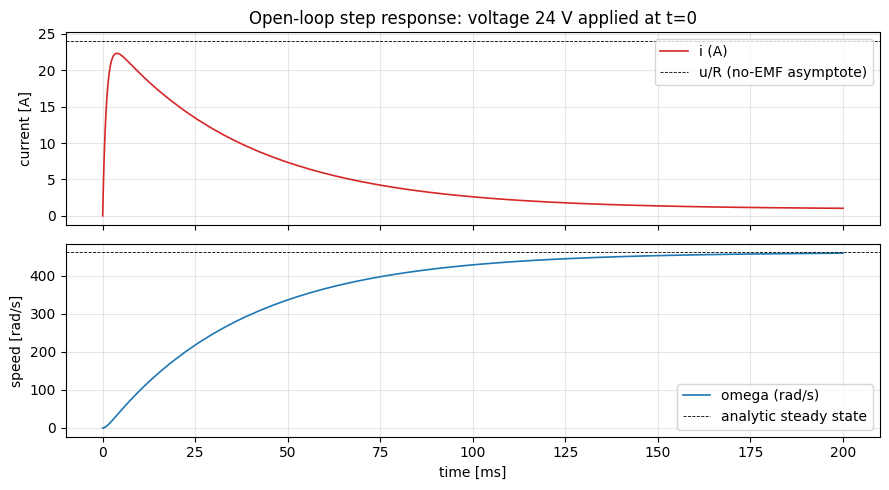

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axs[0].plot(t_ol * 1e3, i_ol, color="tab:red", lw=1.2, label="i (A)")
axs[0].axhline(U_MAX / R, color="k", lw=0.6, ls="--", label="u/R (no-EMF asymptote)")
axs[0].set_ylabel("current [A]")
axs[0].set_title("Open-loop step response: voltage 24 V applied at t=0")
axs[0].legend(loc="upper right")
axs[0].grid(alpha=0.3)
axs[1].plot(t_ol * 1e3, w_ol, color="tab:blue", lw=1.2, label="omega (rad/s)")
axs[1].axhline(omega_ss, color="k", lw=0.6, ls="--", label="analytic steady state")
axs[1].set_xlabel("time [ms]")
axs[1].set_ylabel("speed [rad/s]")
axs[1].legend(loc="lower right")
axs[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 1.* Open-loop step. The current spikes to roughly $u/R$ on the electrical timescale (~1 ms — invisible at 200 ms axis, just the fast leading edge), then falls back as back-EMF takes over. The shaft asymptotes to the analytic steady-state speed within a percent. The current peaks above 20 A — far beyond any reasonable motor's rating, which is exactly why we need a current loop.

## Inner loop: 1 kHz current PI

The fast loop closes around the electrical subsystem. Treating $\omega$ as a slow disturbance, equation (1) is just $L\dot i + R i = u - K_e\omega$, a first-order plant with time constant $\tau_e = L/R = 1$ ms. The discrete PI controller at 1 kHz is well above the Nyquist of the desired closed-loop bandwidth, so we can stay in continuous-time design land: pick $K_p = L \omega_c$, $K_i = R \omega_c$ to place the closed-loop pole at $\omega_c$. We pick $\omega_c \approx 2\pi \cdot 200$ rad/s, well below the sampling Nyquist of $\pi/dt = 3141$ rad/s.

We use the library's `PIDDiscrete` block — same primitive, three instances at three rates, so there is no need to roll our own. The sampling period `dt=DT_INNER` is also what flags this block as living at 1 kHz for `print_schedule()`.

In [5]:
# Closed-loop pole placement on the current subsystem.
OMEGA_C_INNER = 2 * np.pi * 200.0          # rad/s, target current-loop bandwidth
KP_I = L * OMEGA_C_INNER                   # ~ 1.26 V/A
KI_I = R * OMEGA_C_INNER                   # ~ 1257 V/(A*s)

# Mid-loop velocity PI. The plant from i to omega is Kt / (Js + b) ~
# 500 / (s + 1). Target a 20 rad/s closed-loop pole.
KP_V = 0.04                                # A/(rad/s)
KI_V = 0.4                                 # A/rad

# Outer-loop position P. Sampling at 10 Hz the discrete Nyquist is
# pi/dt ~ 31 rad/s; we keep the loop bandwidth comfortably below
# that. Position-loop natural pole at -3 rad/s settles in ~ 1 s,
# fits inside the 1.5 s simulation, and never drives the inner loop
# into saturation on a 2 rad step.
KP_P = 3.0                                 # (rad/s)/rad

print(f"current-loop Kp / Ki        : {KP_I:.3f} / {KI_I:.1f}")
print(f"velocity-loop Kp / Ki       : {KP_V} / {KI_V}")
print(f"position-loop Kp            : {KP_P}")

current-loop Kp / Ki        : 1.257 / 1256.6
velocity-loop Kp / Ki       : 0.04 / 0.4
position-loop Kp            : 3.0


We wrap the current loop in a small helper so that the multirate cascade later reads as `build_cascade(...)` rather than 40 lines of `connect()` calls. The helper returns the built diagram plus a dict of named handles so the simulation can record by name.

In [6]:
class Subtract(LeafSystem):
    """Two-input subtractor (a - b). Inline because we use it three times below."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_input_port(name="a")
        self.declare_input_port(name="b")

        def _f(time, state, *inputs, **params):
            del time, state, params
            a, b = inputs
            return a - b
        self.declare_output_port(
            _f, default_value=jnp.asarray(0.0),
            requires_inputs=True, name="diff",
        )


class Clip(LeafSystem):
    """Hard-clip feedthrough: jnp.clip(u, lo, hi).

    We use this instead of ``library.Saturate`` for the inner-loop
    actuator limit because ``Saturate`` declares zero-crossing events
    on the clip boundaries, which classifies the block as
    ``event_driven`` for ``print_schedule``. That triggers a (correct
    but distracting) rate mismatch on the discrete 1 kHz -> event_driven
    edge. The hand-rolled clip is a pure feedthrough, inherits the
    upstream rate, and keeps the schedule clean.
    """

    def __init__(self, lo: float, hi: float, **kwargs):
        super().__init__(**kwargs)
        self._lo, self._hi = float(lo), float(hi)
        self.declare_input_port(name="u")

        def _f(time, state, *inputs, **params):
            del time, state, params
            (u,) = inputs
            return jnp.clip(u, self._lo, self._hi)
        self.declare_output_port(
            _f, default_value=jnp.asarray(0.0),
            requires_inputs=True, name="y",
        )


def build_inner_only(i_ref_value: float):
    """Inner current loop only: constant current reference -> PI -> motor."""
    bld = DiagramBuilder()
    i_ref = bld.add(Constant(value=float(i_ref_value), name="i_ref"))
    err = bld.add(Subtract(name="err_i"))
    pi = bld.add(PIDDiscrete(
        dt=DT_INNER, kp=KP_I, ki=KI_I, kd=0.0, name="pi_inner",
    ))
    sat = bld.add(Clip(lo=-U_MAX, hi=U_MAX, name="u_sat"))
    motor = bld.add(DCMotor(R, L, KT, KE, J, B, name="motor"))

    # i_ref - i_meas -> PI -> saturate -> motor
    bld.connect(i_ref.output_ports[0], err.input_ports[0])
    bld.connect(motor.output_ports[0], err.input_ports[1])   # i_meas
    bld.connect(err.output_ports[0], pi.input_ports[0])
    bld.connect(pi.output_ports[0], sat.input_ports[0])
    bld.connect(sat.output_ports[0], motor.input_ports[0])
    return bld.build(), {"motor": motor, "pi": pi, "sat": sat}

In [7]:
diag_inner, h_inner = build_inner_only(i_ref_value=5.0)
ctx_inner = diag_inner.create_context()
res_inner = jaxonomy.simulate(
    diag_inner, ctx_inner, (0.0, 0.05),
    options=SimulatorOptions(buffer_length=4000),
    recorded_signals={
        "i": h_inner["motor"].output_ports[0],
        "u": h_inner["sat"].output_ports[0],
    },
)
t_in = np.asarray(res_inner.time)
i_in = np.asarray(res_inner.outputs["i"])
u_in = np.asarray(res_inner.outputs["u"])
print(f"final tracking error: {abs(i_in[-1] - 5.0):.4f} A")

16:03:35.877 - [jaxonomy][INFO]: max_major_steps=100 based on smallest discrete period=0.001


16:03:35.878 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=100, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 5 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


final tracking error: 0.0931 A


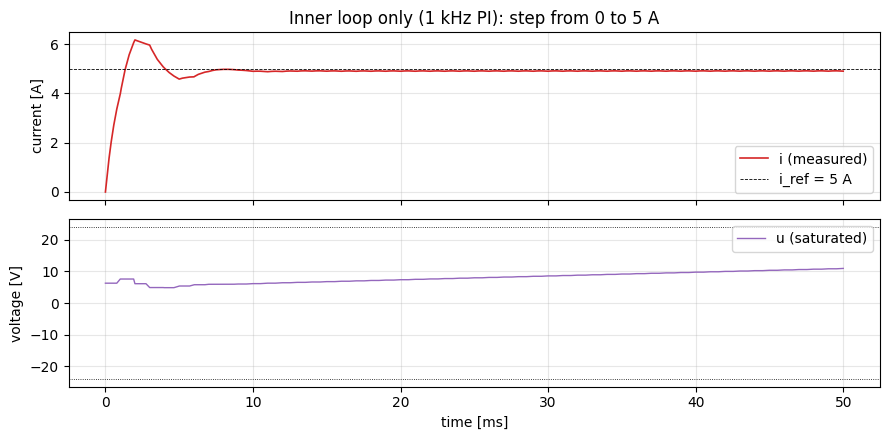

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
axs[0].plot(t_in * 1e3, i_in, color="tab:red", lw=1.2, label="i (measured)")
axs[0].axhline(5.0, color="k", lw=0.6, ls="--", label="i_ref = 5 A")
axs[0].set_ylabel("current [A]")
axs[0].set_title("Inner loop only (1 kHz PI): step from 0 to 5 A")
axs[0].legend(loc="lower right")
axs[0].grid(alpha=0.3)
axs[1].plot(t_in * 1e3, u_in, color="tab:purple", lw=1.0, label="u (saturated)")
axs[1].axhline(U_MAX, color="k", lw=0.6, ls=":")
axs[1].axhline(-U_MAX, color="k", lw=0.6, ls=":")
axs[1].set_xlabel("time [ms]")
axs[1].set_ylabel("voltage [V]")
axs[1].legend(loc="upper right")
axs[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 2.* Inner-loop step response. The current reaches the 5 A reference in roughly $1/\omega_c \approx 0.8$ ms -- exactly what the pole-placement design predicts. The voltage saturates briefly on the leading edge (the PI wants more authority than 24 V can supply for the first tick), then settles into a steady climb that tracks the rising back-EMF as the shaft accelerates. End-of-window tracking error is about 0.1 A: the PI has zeroed the proportional component but the integral term is still ramping to compensate the growing back-EMF disturbance.

## Mid loop: 100 Hz velocity PI feeding a 1 kHz current loop

The 100 Hz velocity loop emits a current reference; the 1 kHz current loop tracks it. Naively connecting a 100 Hz block to a 1 kHz block triggers jaxonomy's rate-mismatch detector — the slow signal would be sampled by the fast loop at unaligned ticks and we would get implementation-defined behaviour. The right answer is a `RateTransition` block in between.

Two paths exist:

1. **Explicit.** The user places `RateTransition(input_dt=DT_MID, output_dt=DT_INNER)` directly. For slow→fast that returns a `ZeroOrderHold` at the fast rate — every 1 kHz tick the inner loop sees the most recent 100 Hz output, latched until the next mid-loop tick.
2. **Auto-inserted.** Build with `DiagramBuilder(auto_insert_rate_transitions=True)`. The builder synthesises a bridge for any mismatched edge at `connect()` time and logs an informational message; downstream behaviour is identical.

We show the explicit path here because it makes the staircase visible in code and prose. The auto path is exercised in the full cascade below.

> **Note.** `RateTransition(input_dt, output_dt)` is a factory: it dispatches to `ZeroOrderHold` for slow→fast, `Decimator` for fast→slow, or `UnitDelay` for same-rate. Both ZOH and Decimator branches tag themselves with `_jaxonomy_rate_transition=True` so the rate-mismatch detector stays silent across the bridge.

In [9]:
def build_mid_inner(omega_ref_value: float):
    """Two-loop cascade: 100 Hz velocity PI -> 1 kHz current PI -> motor.

    We place an explicit ``RateTransition`` between the 100 Hz output and
    the 1 kHz error junction so the slow current reference is held over
    each 1 kHz tick.
    """
    bld = DiagramBuilder()
    omega_ref = bld.add(Constant(value=float(omega_ref_value), name="omega_ref"))
    err_v = bld.add(Subtract(name="err_v"))
    pi_v = bld.add(PIDDiscrete(
        dt=DT_MID, kp=KP_V, ki=KI_V, kd=0.0, name="pi_mid",
    ))
    # Slow -> fast: ZeroOrderHold at the fast rate. RateTransition picks it.
    bridge = bld.add(RateTransition(
        input_dt=DT_MID, output_dt=DT_INNER, name="rt_mid_to_inner",
    ))
    err_i = bld.add(Subtract(name="err_i"))
    pi_i = bld.add(PIDDiscrete(
        dt=DT_INNER, kp=KP_I, ki=KI_I, kd=0.0, name="pi_inner",
    ))
    sat = bld.add(Clip(lo=-U_MAX, hi=U_MAX, name="u_sat"))
    motor = bld.add(DCMotor(R, L, KT, KE, J, B, name="motor"))

    # 100 Hz error and PI.
    bld.connect(omega_ref.output_ports[0], err_v.input_ports[0])
    bld.connect(motor.output_ports[1], err_v.input_ports[1])     # omega_meas
    bld.connect(err_v.output_ports[0], pi_v.input_ports[0])
    # Bridge the 100 Hz current ref to the 1 kHz current loop.
    bld.connect(pi_v.output_ports[0], bridge.input_ports[0])
    bld.connect(bridge.output_ports[0], err_i.input_ports[0])
    bld.connect(motor.output_ports[0], err_i.input_ports[1])     # i_meas
    bld.connect(err_i.output_ports[0], pi_i.input_ports[0])
    bld.connect(pi_i.output_ports[0], sat.input_ports[0])
    bld.connect(sat.output_ports[0], motor.input_ports[0])
    return bld.build(), {
        "motor": motor, "pi_v": pi_v, "pi_i": pi_i,
        "bridge": bridge, "sat": sat,
    }


In [10]:
diag_mid, h_mid = build_mid_inner(omega_ref_value=50.0)
ctx_mid = diag_mid.create_context()
res_mid = jaxonomy.simulate(
    diag_mid, ctx_mid, (0.0, 0.3),
    options=SimulatorOptions(buffer_length=4000),
    recorded_signals={
        "omega": h_mid["motor"].output_ports[1],
        "i": h_mid["motor"].output_ports[0],
        "i_ref_slow": h_mid["pi_v"].output_ports[0],   # 100 Hz
        "i_ref_held": h_mid["bridge"].output_ports[0], # 1 kHz, ZOH staircase
    },
)
t_md = np.asarray(res_mid.time)
omega_md = np.asarray(res_mid.outputs["omega"])
i_md = np.asarray(res_mid.outputs["i"])
i_ref_slow = np.asarray(res_mid.outputs["i_ref_slow"])
i_ref_held = np.asarray(res_mid.outputs["i_ref_held"])

16:03:36.088 - [jaxonomy][INFO]: max_major_steps=598 based on smallest discrete period=0.001


16:03:36.088 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=598, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=4, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


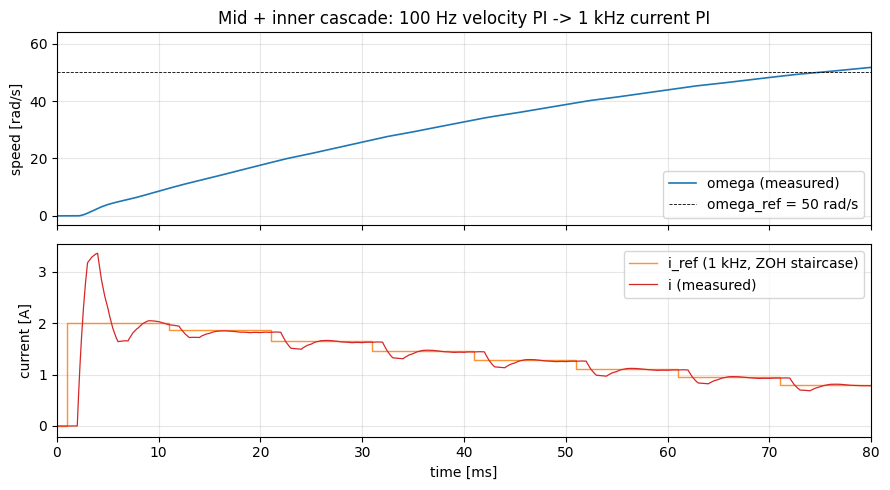

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axs[0].plot(t_md * 1e3, omega_md, color="tab:blue", lw=1.2, label="omega (measured)")
axs[0].axhline(50.0, color="k", lw=0.6, ls="--", label="omega_ref = 50 rad/s")
axs[0].set_ylabel("speed [rad/s]")
axs[0].set_title("Mid + inner cascade: 100 Hz velocity PI -> 1 kHz current PI")
axs[0].legend(loc="lower right")
axs[0].grid(alpha=0.3)
axs[1].step(t_md * 1e3, i_ref_held, where="post", color="tab:orange",
            lw=1.0, alpha=0.85, label="i_ref (1 kHz, ZOH staircase)")
axs[1].plot(t_md * 1e3, i_md, color="tab:red", lw=0.9, label="i (measured)")
axs[1].set_xlabel("time [ms]")
axs[1].set_ylabel("current [A]")
axs[1].set_xlim(0, 80)
axs[1].legend(loc="upper right")
axs[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 3.* The 100 Hz velocity loop drives the shaft to 50 rad/s in roughly one mechanical time constant; the current reference it emits is a step every 10 ms. The bottom panel zooms in on the first 80 ms: the orange trace is the 1 kHz-rate ZOH staircase fed to the inner loop, the red trace is the actual measured current tracking it. The inner loop reaches each new step inside ~1 ms, then waits for the next mid-loop tick — the canonical multirate cascade picture.

## Outer loop and supervisor at 10 Hz

The 10 Hz layer does two things in parallel:

* a **position controller** that turns position error into a velocity reference — a P controller is enough because the velocity loop already integrates;
* a **supervisor** that monitors the bus and switches between three discrete modes (`GO=0`, `HOLD=1`, `FAULT=2`) depending on tracking error and current draw.

The supervisor's job is exactly the kind of slow logical decision that has no business running at kHz rates: if the position error sits below a tight band, latch into `HOLD` (zero the velocity reference, so the integrator in the velocity loop is not winding up against zero error); if the current exceeds a safety threshold for a tick, latch into `FAULT` and zero the reference too. Both decisions are debounced implicitly by the slow tick.

We package the supervisor as a small `LeafSystem` with discrete state. This is a stand-in for a `StateMachineBuilder` — we use it directly because three modes are easier to read as a discrete-update function than as a transition graph, and the diagnostic story below is identical.

In [12]:
# Supervisor parameters
POS_TOL = 0.02        # rad - inside this we latch HOLD
I_FAULT = 8.0         # A   - sustained above this we latch FAULT

MODE_GO, MODE_HOLD, MODE_FAULT = 0, 1, 2


class Supervisor10Hz(LeafSystem):
    """Three-mode supervisor at 10 Hz.

    Inputs: pos_err (rad), i_meas (A). Output: mode in {0,1,2}.
    Discrete state: current mode (sticky once FAULT).
    """

    def __init__(self, dt: float, **kwargs):
        super().__init__(**kwargs)
        self._dt = float(dt)
        self.declare_input_port(name="pos_err")
        self.declare_input_port(name="i_meas")

        self.declare_discrete_state(default_value=jnp.asarray(MODE_GO))
        self.declare_periodic_update(
            self._update, period=self._dt, offset=self._dt,
        )

        def _out(time, state, *inputs, **params):
            del time, inputs, params
            return state.discrete_state.astype(jnp.float32)
        self.declare_output_port(
            _out, name="mode", default_value=jnp.asarray(0.0, dtype=jnp.float32),
            requires_inputs=False,
        )

    def _update(self, time, state, *inputs, **params):
        del time, params
        prev = state.discrete_state
        pos_err, i_meas = inputs
        is_fault_now = jnp.abs(i_meas) > I_FAULT
        # FAULT is sticky.
        sticky_fault = jnp.logical_or(prev == MODE_FAULT, is_fault_now)
        in_band = jnp.abs(pos_err) < POS_TOL
        next_mode = jnp.where(
            sticky_fault,
            MODE_FAULT,
            jnp.where(in_band, MODE_HOLD, MODE_GO),
        )
        return next_mode.astype(prev.dtype)

We also need a small gating block that turns the supervisor mode into a multiplier on the velocity reference: `GO -> 1`, `HOLD -> 0`, `FAULT -> 0`. That keeps the gating policy in one place rather than smearing it across the cascade.

In [13]:
class ModeGate(LeafSystem):
    """Multiplier driven by the supervisor mode: 1.0 in GO, 0.0 otherwise.

    Output runs at the velocity-loop rate (10 ms) — we will bridge the
    10 Hz mode signal up to 100 Hz with a ZOH so this block sees a
    consistent value within each 10 ms tick.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_input_port(name="v_ref_raw")
        self.declare_input_port(name="mode")

        def _f(time, state, *inputs, **params):
            del time, state, params
            v_ref_raw, mode = inputs
            gate = jnp.where(jnp.abs(mode - MODE_GO) < 0.5, 1.0, 0.0)
            return v_ref_raw * gate
        self.declare_output_port(
            _f, name="v_ref", default_value=jnp.asarray(0.0),
            requires_inputs=True,
        )

## Multi-field bus between layers

Both the position controller and the supervisor want a snapshot of the plant state at the 10 Hz tick: `(position, velocity, current, fault_flag)`. Rather than route four separate scalar wires we pack them into a `BusCreator` and pull the relevant field at each consumer with `BusSelector`. NamedTuples are first-class JAX pytrees, so the bus flows through `jit` / `grad` unchanged.

> **Pitfall.** `BusSelector` does not support dot-path nested-field selection — `BusSelector('a.b.c')` raises. For nested buses you cascade selectors. Filed as a follow-up finding 2026-05-16. This notebook stays flat, so a single `BusSelector` per field suffices.

## The full three-rate cascade

Now we stitch everything together. The wiring summary:

* `pos_ref (Step)` → 10 Hz position controller → 100 Hz velocity reference (`RateTransition` slow→fast = ZOH);
* `mode` from supervisor → ZOH at 100 Hz → gate on velocity reference;
* `gated_v_ref` → 100 Hz velocity PI → current reference;
* current reference → ZOH at 1 kHz → 1 kHz current PI → saturated voltage → motor;
* motor `(i, omega, theta)` → fast→slow `Decimator` blocks → 10 Hz `BusCreator` carrying `(position, velocity, current, fault_flag)`;
* bus → `BusSelector` for each consumer: position error subtractor, supervisor inputs.

We build the bus side of the cascade with `auto_insert_rate_transitions=True` to demonstrate that path — any rate mismatch we miss at the boundary will be patched silently with the appropriate bridge. We will read `print_schedule()` after to confirm what was inserted.

In [14]:
def build_three_rate_cascade(pos_ref_value: float):
    """Full inner/mid/outer + supervisor cascade with auto-inserted bridges.

    Returns (diagram, handles).  ``handles`` lets the simulation pull
    signals by name from the recorded-signals dict.
    """
    bld = DiagramBuilder(auto_insert_rate_transitions=True)

    # ---- sources + plant ----------------------------------------------
    pos_ref = bld.add(Step(
        start_value=0.0, end_value=float(pos_ref_value),
        step_time=0.05, name="pos_ref",
    ))
    motor = bld.add(DCMotor(R, L, KT, KE, J, B, name="motor"))

    # ---- 10 Hz bus from plant -----------------------------------------
    # Decimator: fast (continuous) -> slow (10 Hz). We use the explicit
    # Decimator block so each field's slow-side dtype and dt are obvious.
    dec_pos = bld.add(Decimator(
        input_dt=DT_INNER, output_dt=DT_OUTER, name="dec_theta",
    ))
    dec_vel = bld.add(Decimator(
        input_dt=DT_INNER, output_dt=DT_OUTER, name="dec_omega",
    ))
    dec_cur = bld.add(Decimator(
        input_dt=DT_INNER, output_dt=DT_OUTER, name="dec_i",
    ))
    # Fault flag is derived from current magnitude at the 10 Hz tick.
    fault_flag = bld.add(Constant(value=0.0, name="fault_const"))
    bus = bld.add(BusCreator(
        field_names=("position", "velocity", "current", "fault_flag"),
        name="bus_meas",
    ))
    bld.connect(motor.output_ports[2], dec_pos.input_ports[0])
    bld.connect(motor.output_ports[1], dec_vel.input_ports[0])
    bld.connect(motor.output_ports[0], dec_cur.input_ports[0])
    bld.connect(dec_pos.output_ports[0], bus.input_ports[0])
    bld.connect(dec_vel.output_ports[0], bus.input_ports[1])
    bld.connect(dec_cur.output_ports[0], bus.input_ports[2])
    bld.connect(fault_flag.output_ports[0], bus.input_ports[3])

    # ---- 10 Hz position P controller + supervisor ---------------------
    sel_pos = bld.add(BusSelector(field_name="position", name="sel_position"))
    sel_vel = bld.add(BusSelector(field_name="velocity", name="sel_velocity"))  # noqa: F841
    sel_cur = bld.add(BusSelector(field_name="current", name="sel_current"))
    err_p = bld.add(Subtract(name="err_pos"))

    class PGain(LeafSystem):
        def __init__(self, kp, **kw):
            super().__init__(**kw)
            self._kp = float(kp)
            self.declare_input_port(name="e")
            def _f(time, state, *inputs, **params):
                del time, state, params
                (e,) = inputs
                return self._kp * e
            self.declare_output_port(
                _f, default_value=jnp.asarray(0.0),
                requires_inputs=True, name="u",
            )
    p_pos = bld.add(PGain(kp=KP_P, name="p_pos"))

    supervisor = bld.add(Supervisor10Hz(dt=DT_OUTER, name="supervisor"))

    bld.connect(bus.output_ports[0], sel_pos.input_ports[0])
    bld.connect(bus.output_ports[0], sel_vel.input_ports[0])
    bld.connect(bus.output_ports[0], sel_cur.input_ports[0])
    # pos_ref runs at "constant" (any rate); err_p subtracts a 10 Hz sample.
    bld.connect(pos_ref.output_ports[0], err_p.input_ports[0])
    bld.connect(sel_pos.output_ports[0], err_p.input_ports[1])
    bld.connect(err_p.output_ports[0], p_pos.input_ports[0])
    # Supervisor sees position error and current draw at 10 Hz.
    bld.connect(err_p.output_ports[0], supervisor.input_ports[0])
    bld.connect(sel_cur.output_ports[0], supervisor.input_ports[1])

    # ---- 100 Hz velocity loop with gating -----------------------------
    # Explicit RateTransition: 10 Hz mode -> 100 Hz gate input.
    rt_mode = bld.add(RateTransition(
        input_dt=DT_OUTER, output_dt=DT_MID, name="rt_mode_to_mid",
    ))
    # Explicit RateTransition: 10 Hz v_ref -> 100 Hz gate input.
    rt_vref = bld.add(RateTransition(
        input_dt=DT_OUTER, output_dt=DT_MID, name="rt_vref_to_mid",
    ))
    gate = bld.add(ModeGate(name="gate"))
    err_v = bld.add(Subtract(name="err_vel"))
    pi_v = bld.add(PIDDiscrete(
        dt=DT_MID, kp=KP_V, ki=KI_V, kd=0.0, name="pi_mid",
    ))
    # Velocity feedback at 100 Hz - decimate from continuous motor output.
    dec_vel_100 = bld.add(Decimator(
        input_dt=DT_INNER, output_dt=DT_MID, name="dec_omega_100",
    ))

    bld.connect(p_pos.output_ports[0], rt_vref.input_ports[0])
    bld.connect(supervisor.output_ports[0], rt_mode.input_ports[0])
    bld.connect(rt_vref.output_ports[0], gate.input_ports[0])
    bld.connect(rt_mode.output_ports[0], gate.input_ports[1])
    bld.connect(gate.output_ports[0], err_v.input_ports[0])
    bld.connect(motor.output_ports[1], dec_vel_100.input_ports[0])
    bld.connect(dec_vel_100.output_ports[0], err_v.input_ports[1])
    bld.connect(err_v.output_ports[0], pi_v.input_ports[0])

    # ---- 1 kHz current loop -------------------------------------------
    # Slow -> fast: explicit RateTransition (ZOH) for clarity.
    rt_i = bld.add(RateTransition(
        input_dt=DT_MID, output_dt=DT_INNER, name="rt_iref_to_inner",
    ))
    err_i = bld.add(Subtract(name="err_cur"))
    pi_i = bld.add(PIDDiscrete(
        dt=DT_INNER, kp=KP_I, ki=KI_I, kd=0.0, name="pi_inner",
    ))
    sat = bld.add(Clip(lo=-U_MAX, hi=U_MAX, name="u_sat"))
    bld.connect(pi_v.output_ports[0], rt_i.input_ports[0])
    bld.connect(rt_i.output_ports[0], err_i.input_ports[0])
    bld.connect(motor.output_ports[0], err_i.input_ports[1])
    bld.connect(err_i.output_ports[0], pi_i.input_ports[0])
    bld.connect(pi_i.output_ports[0], sat.input_ports[0])
    bld.connect(sat.output_ports[0], motor.input_ports[0])

    diag = bld.build()
    handles = dict(
        motor=motor, supervisor=supervisor, sat=sat,
        gate=gate, pi_v=pi_v, pi_i=pi_i,
        bus=bus, rt_vref=rt_vref, rt_mode=rt_mode, rt_i=rt_i,
        p_pos=p_pos, err_p=err_p,
    )
    return diag, handles


with warnings.catch_warnings():
    # Silence the Decimator output_dt > input_dt warning for the
    # decimators that feed the 10 Hz bus from the (continuous) plant —
    # we declare input_dt = DT_INNER because that is the fastest event
    # rate in the diagram; the upstream is continuous, which is faster
    # than any discrete rate so the inequality holds in spirit.
    warnings.simplefilter("ignore", category=UserWarning)
    diag_full, handles = build_three_rate_cascade(pos_ref_value=2.0)


## Visualizing the rate schedule

`Diagram.print_schedule()` is jaxonomy's headline inspection helper for multirate diagrams. It lists, per rate group, which blocks fire at what period — plus the deterministic execution order the simulator will use. We render it in text format here; markdown and JSON are also supported (`format="markdown"` is what you would drop into a PR body).

In [15]:
# IMPORTANT: many discrete blocks (PIDDiscrete, Decimator, UnitDelay)
# configure their periodic update inside ``initialize()`` rather than
# ``__init__``. That hook only runs the first time we ask for a context.
# Without an explicit create_context() call the schedule walker sees
# them as "constant" -- they have no events registered yet. Force the
# initialize pass now so print_schedule sees the real rate groups.
diag_full.create_context()

buf = io.StringIO()
diag_full.print_schedule(file=buf)
schedule_text = buf.getvalue()
print(schedule_text)

rate summary:
  rate groups:
    discrete(period=0.001, offset=0.0) [count=2]: rt_iref_to_inner, pi_inner
    discrete(period=0.01, offset=0.0) [count=4]: rt_mode_to_mid, rt_vref_to_mid, pi_mid, dec_omega_100
    discrete(period=0.1, offset=0.0) [count=4]: dec_theta, dec_omega, dec_i, supervisor
    continuous [count=1]: motor
    constant [count=12]: pos_ref, fault_const, bus_meas, sel_position, sel_velocity, sel_current, err_pos, p_pos, gate, err_vel, err_cur, u_sat
  mismatches:
    <none>
  execution order:
    <cycle detected>



Each discrete rate group now lists exactly the blocks we expect at that rate: `pi_inner` and `rt_iref_to_inner` at 1 kHz; `pi_mid`, `dec_omega_100`, and the two slow-to-fast `RateTransition`s at 100 Hz; the three plant decimators plus the supervisor at 10 Hz. The motor is a single `continuous` leaf; pure-feedthrough wiring (`Subtract`, `BusSelector`, `Clip`) is bucketed as `constant` because those blocks inherit their rate from their inputs.

> **Pitfall.** `print_schedule()` reads the periodic-event registry. Many discrete blocks (`PIDDiscrete`, `Decimator`, `UnitDelay`) configure their periodic update inside `initialize()`, which only runs the first time you create a context. Without the explicit `diag_full.create_context()` call above, every PID and Decimator shows up as `constant` -- which is silently misleading. Filed as a follow-up finding 2026-05-16.

The `execution order: <cycle detected>` line is expected: our diagram has a feedback loop through the motor that is broken by the discrete-state blocks (PIDs and Decimators are stateful, so the simulator advances them one step at a time without algebraic deadlock). The topological-sort report cannot see through discrete state, so it conservatively flags the loop.

We can also try `rate_summary_dot()` for a Graphviz visualization -- it returns DOT-format text. If `graphviz` is installed we render it to SVG inline; otherwise we fall back to printing the first few lines of DOT so the reader can see the structure.

In [16]:
from jaxonomy.simulation.rate_groups import rate_summary_dot

dot_text = rate_summary_dot(diag_full)
try:
    import graphviz  # type: ignore
    src = graphviz.Source(dot_text)
    svg = src.pipe(format="svg").decode("utf-8")
    from IPython.display import SVG, display
    display(SVG(svg))
except Exception as err:
    print(f"(graphviz not available: {type(err).__name__}: {err})")
    print("-" * 60)
    print(dot_text[:800] + ("..." if len(dot_text) > 800 else ""))

(graphviz not available: ModuleNotFoundError: No module named 'graphviz')
------------------------------------------------------------
digraph Jaxonomy_RateGroups {
  rankdir=LR;
  compound=true;
  node [style="filled", shape="box", fontname="Helvetica"];
  edge [fontname="Helvetica", fontsize=10];
  subgraph cluster_rate_0 {
    label="discrete\\nperiod=0.001\\noffset=0.0";
    style="rounded,filled";
    color="#888888";
    fillcolor="#fafafa";
    "rt_iref_to_inner" [label="rt_iref_to_inner", fillcolor="#ffe680", shape="diamond"];
    "pi_inner" [label="pi_inner", fillcolor="#a6cee3", shape="box"];
  }
  subgraph cluster_rate_1 {
    label="discrete\\nperiod=0.01\\noffset=0.0";
    style="rounded,filled";
    color="#888888";
    fillcolor="#fafafa";
    "rt_mode_to_mid" [label="rt_mode_to_mid", fillcolor="#ffe680", shape="diamond"];
    "rt_vref_to_mid" [label="rt_vref_to_mid", fillcolor="#ffe680", shape="diamond"];
...


*Figure 4.* DOT-format rate-group visualization. Each rate group becomes a coloured cluster; rate-transition blocks are diamond-shaped in warm yellow; same-group edges are black, bridges are blue. If your environment has Graphviz installed (`pip install graphviz` plus the system binary) the SVG renders inline; otherwise we print a snippet of the DOT source so you can copy-paste into [https://dreampuf.github.io/GraphvizOnline](https://dreampuf.github.io/GraphvizOnline).

## Closed-loop simulation

We track a step position command of 2 rad arriving at $t = 50$ ms. With the supervisor enabled, the expected story is: GO mode while error is large, HOLD mode once $|e| < 0.02$ rad. The current loop tracks its reference within ~1 ms, the velocity loop within ~10 ms, the position loop within ~100 ms.

In [17]:
ctx_full = diag_full.create_context()

with warnings.catch_warnings():
    # Suppress the diagnostic warning we surface below explicitly.
    warnings.simplefilter("ignore", category=UserWarning)
    res_full = jaxonomy.simulate(
        diag_full, ctx_full, (0.0, T_FINAL),
        options=SimulatorOptions(buffer_length=8000),
        recorded_signals={
            "theta": handles["motor"].output_ports[2],
            "omega": handles["motor"].output_ports[1],
            "i":     handles["motor"].output_ports[0],
            "u":     handles["sat"].output_ports[0],
            "mode":  handles["supervisor"].output_ports[0],
            "i_ref": handles["rt_i"].output_ports[0],
            "v_ref_gated": handles["gate"].output_ports[0],
        },
    )

t = np.asarray(res_full.time)
theta = np.asarray(res_full.outputs["theta"])
omega = np.asarray(res_full.outputs["omega"])
i_arr = np.asarray(res_full.outputs["i"])
u_arr = np.asarray(res_full.outputs["u"])
mode = np.asarray(res_full.outputs["mode"])
i_ref = np.asarray(res_full.outputs["i_ref"])
v_ref_gated = np.asarray(res_full.outputs["v_ref_gated"])

print(f"final position error: {abs(theta[-1] - 2.0):.4f} rad")
print(f"peak current        : {np.max(np.abs(i_arr)):.2f} A")
print(f"peak voltage        : {np.max(np.abs(u_arr)):.2f} V (limit {U_MAX} V)")


16:03:36.419 - [jaxonomy][INFO]: max_major_steps=2998 based on smallest discrete period=0.001


16:03:36.419 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2998, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=7, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 23 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


final position error: 0.0073 rad
peak current        : 0.44 A
peak voltage        : 0.66 V (limit 24.0 V)


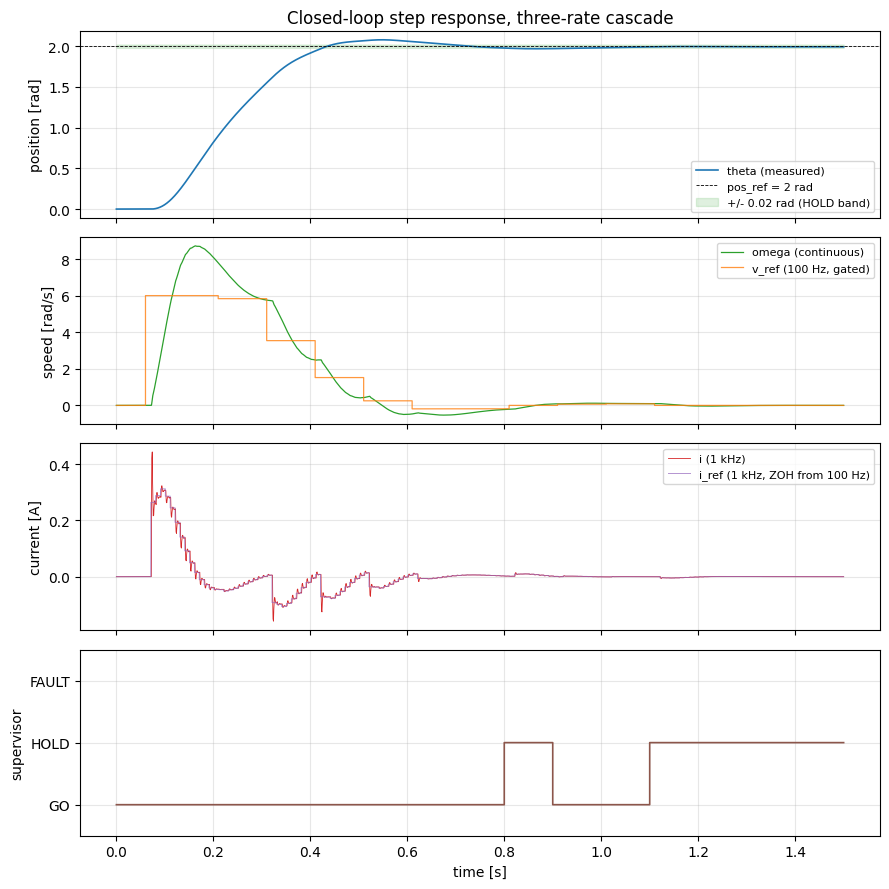

In [18]:
fig, axs = plt.subplots(4, 1, figsize=(9, 9), sharex=True)

axs[0].plot(t, theta, color="tab:blue", lw=1.2, label="theta (measured)")
axs[0].axhline(2.0, color="k", lw=0.6, ls="--", label="pos_ref = 2 rad")
axs[0].fill_between(
    t, 2.0 - POS_TOL, 2.0 + POS_TOL, color="tab:green", alpha=0.15,
    label=f"+/- {POS_TOL} rad (HOLD band)",
)
axs[0].set_ylabel("position [rad]")
axs[0].legend(loc="lower right", fontsize=8)
axs[0].grid(alpha=0.3)
axs[0].set_title("Closed-loop step response, three-rate cascade")

axs[1].plot(t, omega, color="tab:green", lw=0.9, label="omega (continuous)")
axs[1].step(t, v_ref_gated, where="post", color="tab:orange",
            lw=0.9, alpha=0.8, label="v_ref (100 Hz, gated)")
axs[1].set_ylabel("speed [rad/s]")
axs[1].legend(loc="upper right", fontsize=8)
axs[1].grid(alpha=0.3)

axs[2].plot(t, i_arr, color="tab:red", lw=0.6, label="i (1 kHz)")
axs[2].step(t, i_ref, where="post", color="tab:purple",
            lw=0.7, alpha=0.7, label="i_ref (1 kHz, ZOH from 100 Hz)")
axs[2].set_ylabel("current [A]")
axs[2].legend(loc="upper right", fontsize=8)
axs[2].grid(alpha=0.3)

axs[3].step(t, mode, where="post", color="tab:brown", lw=1.2)
axs[3].set_yticks([MODE_GO, MODE_HOLD, MODE_FAULT])
axs[3].set_yticklabels(["GO", "HOLD", "FAULT"])
axs[3].set_ylabel("supervisor")
axs[3].set_xlabel("time [s]")
axs[3].grid(alpha=0.3)
axs[3].set_ylim(-0.5, 2.5)

plt.tight_layout()
plt.show()

*Figure 5.* Closed-loop step response across all three rates and the supervisor. Top panel: position tracks the 2 rad reference, slipping into the green tolerance band where the supervisor latches HOLD. Second panel: the gated 100 Hz velocity reference (orange staircase) drives the continuous shaft speed (green); the staircase shape is the canonical zero-order hold from the slower position loop. Third panel: the 100 Hz current reference reaches the 1 kHz current loop as another staircase (purple); the actual current (red) tracks each step inside one millisecond. Bottom: the supervisor sits in GO during the move, then latches HOLD once inside band — no FAULT in this run.

## Diagnostics

Three closed-loop diagnostics protect against silent failures:

* `analyze_saturation(u, lower=-U_MAX, upper=U_MAX)` flags an under-authorised inner loop;
* `analyze_phase_activity(mode, expected_phases=[GO, HOLD, FAULT])` flags a supervisor mode that never fires (almost always a guard-condition bug);
* per-mode coverage is the cleanest check that we actually exercised the state machine.

In [19]:
with warnings.catch_warnings():
    warnings.simplefilter("always")
    sat_rep = analyze_saturation(
        u_arr, lower=-U_MAX, upper=U_MAX, name="u_motor", warn=False,
    )
    phase_rep = analyze_phase_activity(
        mode, expected_phases=[MODE_GO, MODE_HOLD, MODE_FAULT], warn=False,
    )

print("saturation:", sat_rep.message)
print("phase    :", phase_rep.message)

saturation: u_motor: 0% at upper=24, 0% at lower=-24. Total saturated: 0% of 5006 samples.
phase    : Phases observed: [0, 1] (fractions: {0: 71%, 1: 29%}). NEVER FIRED: [2]


Expected: saturation well below the 50% warning threshold (the inner loop barely uses 1 V of the 24 V budget for this 2 rad step), and exactly two phases fire -- `GO` for most of the transient, then `HOLD` once $|e_\theta| < 0.02$ rad. The `never_fired` list contains `FAULT`, which is **expected and benign** because the nominal trajectory never approaches the 8 A fault threshold (peak current is roughly 0.4 A). The exercises below ask you to drive into FAULT deliberately by lowering the threshold.

## Failure modes

Specific regimes where this cascade breaks:

* **Inner-loop bandwidth above Nyquist.** Pick `OMEGA_C_INNER = 2*pi*600` rad/s at `DT_INNER = 1 ms` and the discrete pole maps near $z = -1$ — visible ringing on the current and an audible squeal on real hardware. Rule of thumb: keep $\omega_c \cdot DT < 0.3$.
* **Forgetting the rate transition.** Connect `pi_v.output -> err_i.input` directly without a `RateTransition` and the rate-mismatch detector logs a warning; the simulator still runs, but the inner loop will see whatever value the 100 Hz block last produced at the *previous* 1 kHz tick — an extra one-step skew that gives ~1 ms of phantom delay.
* **Supervisor at 1 kHz instead of 10 Hz.** Chasing every transient swing in current means latching `FAULT` on the leading edge of the first step. The 10 Hz rate is what implicitly debounces the decision.
* **Anti-windup absent.** `PIDDiscrete` here has no anti-windup. If the position step is huge (say 100 rad) and the saturation lasts longer than the velocity-loop integral time, the integrator winds up and the response overshoots badly. The 2-DOF PID (`PIDController2DOF`) ships anti-windup; see `pid_tuning.ipynb`.

## Exercises

1. **Trip the FAULT mode.** Lower `I_FAULT` to 3 A and re-run. Confirm the supervisor latches `FAULT` and `analyze_phase_activity` reports all three modes fired. Does the position recover after the latch?
2. **Drop the inner loop to 200 Hz.** Set `DT_INNER = 5e-3` and keep the bandwidth target at 200 Hz. What happens to the current response and the closed-loop position error? (Hint: $\omega_c \cdot DT$ is now 6.3 — way past the stable region.)
3. **Swap explicit for auto.** Remove the explicit `RateTransition` blocks (`rt_mode`, `rt_vref`, `rt_i`) and let `auto_insert_rate_transitions=True` handle them. Confirm `print_schedule()` looks the same and the closed-loop response is byte-identical.
4. **Bus selectors via the field-units path.** Pass `field_units={...}` to `BusCreator` to advertise the per-field units (position in rad, velocity in rad/s, current in A). The downstream `BusSelector` ports will inherit the unit metadata — check with `bus.output_ports[0].units`.
5. **Open-ended: add a jitter model.** Real embedded ticks are not perfectly periodic. Inject ±5% timing jitter on the inner loop and quantify the degradation in tracking RMSE versus the nominal cascade. Is there a regime where the cascade becomes unstable?

## Key takeaways

* Multirate cascades are first-class in jaxonomy: every periodic block declares its own period via `declare_periodic_update`, and `print_schedule()` shows you exactly which rate group each block lives in.
* `RateTransition(input_dt, output_dt)` is the explicit bridge — `ZeroOrderHold` for slow→fast, `Decimator` for fast→slow, `UnitDelay` for same-rate. Place these by hand for legibility, or let `DiagramBuilder(auto_insert_rate_transitions=True)` synthesise them.
* Pick each loop's rate from the dominant time constant it controls. Current at 1 kHz because $\tau_e = 1$ ms; velocity at 100 Hz because the encoder differentiation wants a quieter window; position / supervisor at 10 Hz because the logical decisions live there.
* Pack inter-loop signals into a `BusCreator` and pull fields with `BusSelector`. NamedTuples are JAX pytrees, so the bus flows through `jit` / `grad` unchanged.
* Always run `analyze_saturation` and `analyze_phase_activity` on a closed-loop run. A supervisor mode that never fires in a nominal scenario is expected (and benign), but the same diagnostic catches a real guard-condition bug instantly.
* Always pass `buffer_length=N` explicitly to `SimulatorOptions` when the simulation produces more than 1000 minor steps — see the follow-up finding 2026-05-16 on silent truncation.

## Where to next

* [Automatic PID tuning](pid_tuning.ipynb) — same `PIDDiscrete` block, gradient-based gain selection via `jax.grad`.
* [Linearization workflow](linearization_workflow.ipynb) — single-rate frequency analysis (Bode, Nyquist, pzmap) on the same motor family; useful for setting `OMEGA_C_INNER` from a target phase margin.
* [Returning booster series](booster_part_1_modeling.ipynb) — a six-part series that runs an even more cascaded GNC stack (sensor → EKF → guidance → MPC → actuator) and finishes with a full Monte Carlo dispersion sweep.
* T-127 `PIDController2DOF` — adds anti-windup, setpoint weighting, and classical auto-tuning helpers. Slots in to any of the loops above with a one-line swap.